# Spectral Clustering - Step by Step

This notebook builds spectral clustering **from scratch**, following the exact pipeline from the *29.2 Spectral Clustering Handout*:

> **Points -> Similarity graph -> W -> D -> Laplacian L -> Eigenvectors -> K-means**

  - Step 0: Data
  - Step 1: Build a similarity graph
  - Step 2: Form the similarity matrix `W`
  - Step 3: Form the degree matrix `D`
  - Step 4: Compute the Laplacian `L = D - W`
  - Step 5: Eigen-decompose `L` and **choose k using the eigengap**
  - Step 6: Build the spectral embedding `U` - the **unfolding** step
  - Step 7: Run k-means on the rows of `U`
  - Final comparison against ordinary k-means and sklearn's `SpectralClustering`

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.linalg import eigh
from sklearn.datasets import make_moons
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import adjusted_rand_score

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

### Step 0 - Create the Sample Data

Two variables only: `V1` and `V2`.

In [ ]:
X, true_labels = make_moons(n_samples=120, noise=0.07, random_state=42)

df = pd.DataFrame(X, columns=["V1", "V2"])
df

,V1,V2
0,-0.756377,0.694812
1,-0.779523,0.664656
2,0.943861,0.198386
3,-1.054847,0.127648
4,0.242166,1.077621
...,...,...
115,1.759209,-0.097062
116,0.754444,0.634723
117,1.118157,-0.525663
118,-0.951890,0.472684


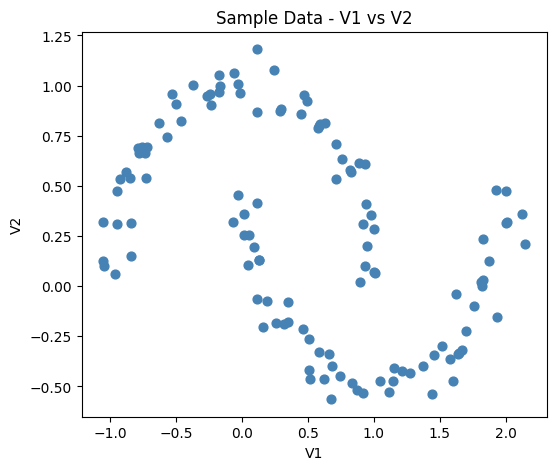

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(df["V1"], df["V2"], s=40, color="steelblue")
plt.title("Sample Data - V1 vs V2")
plt.xlabel("V1"); plt.ylabel("V2")
plt.show()

### Why not just use k-means?

"A straight split cuts through the shape". Let's confirm that on our own data before doing anything spectral.

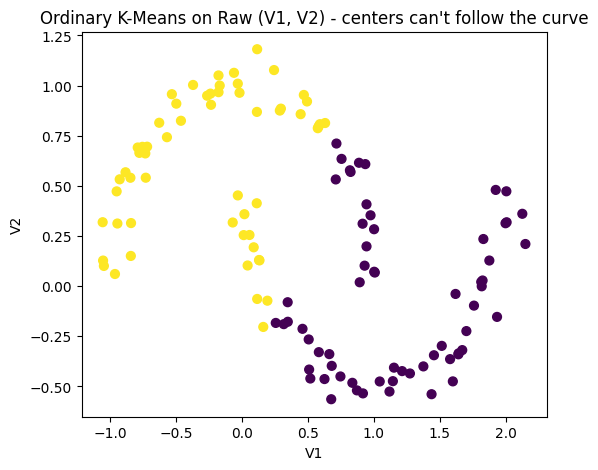

In [ ]:
kmeans_naive = KMeans(n_clusters=2, n_init=10, random_state=42).fit(df[["V1", "V2"]])

plt.figure(figsize=(6, 5))
plt.scatter(df["V1"], df["V2"], c=kmeans_naive.labels_, cmap="viridis", s=40)
plt.title("Ordinary K-Means on Raw (V1, V2) - centers can't follow the curve")
plt.xlabel("V1"); plt.ylabel("V2")
plt.show()

### Step 1 - Build a Similarity Graph

A **k-nearest-neighbor graph** - connect each point to its k closest points, then symmetrize

In [ ]:
n = X.shape[0]
k_neighbors = 10

nn = NearestNeighbors(n_neighbors=k_neighbors + 1).fit(X)  # +1: a point is its own nearest neighbor
_, indices = nn.kneighbors(X)

A = np.zeros((n, n))

for i in range(n):

    A[i, indices[i, 1:]] = 1   # skip index 0 (the point itself)

A_sym = np.maximum(A, A.T)     # symmetrize: connect if EITHER side calls it a neighbor
np.fill_diagonal(A_sym, 0)

print(f"Similarity graph built with k = {k_neighbors} nearest neighbors.")
print(f"Average node degree (unweighted): {A_sym.sum(axis=1).mean():.2f}")

Similarity graph built with k = 10 nearest neighbors.
Average node degree (unweighted): 11.22


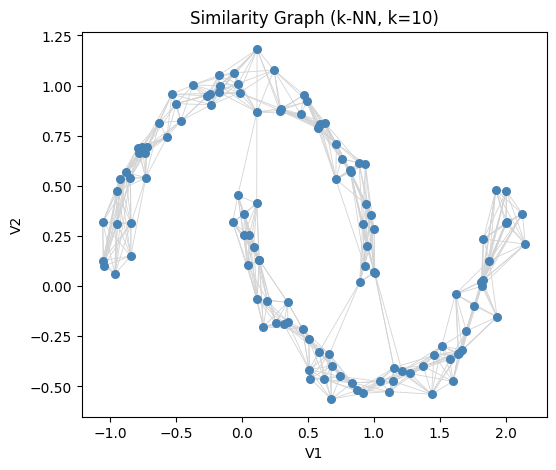

In [ ]:
plt.figure(figsize=(6, 5))
edge_i, edge_j = np.where(np.triu(A_sym) > 0)

for i, j in zip(edge_i, edge_j):

    plt.plot([X[i, 0], X[j, 0]], [X[i, 1], X[j, 1]], color="lightgray", linewidth=0.6, zorder=1)

plt.scatter(X[:, 0], X[:, 1], color="steelblue", s=30, zorder=2)
plt.title(f"Similarity Graph (k-NN, k={k_neighbors})")
plt.xlabel("V1"); plt.ylabel("V2")
plt.show()

### Step 2 - Turn the Graph into the Similarity Matrix W

We only keep weights on edges that exist in the graph above - everything else is treated as "no edge."

In [ ]:
sq_dists = np.sum(X**2, axis=1)[:, None] + np.sum(X**2, axis=1)[None, :] - 2 * X @ X.T
sq_dists = np.clip(sq_dists, 0, None)  # guard tiny negative values from floating-point error

sigma = np.median(np.sqrt(sq_dists[sq_dists > 0]))  # median-distance heuristic for the RBF scale

W = np.exp(-sq_dists / (2 * sigma**2)) * A_sym  # RBF weight, restricted to graph edges
np.fill_diagonal(W, 0)

print(f"RBF scale sigma = {sigma:.3f}")
print("W is symmetric:", np.allclose(W, W.T))
pd.DataFrame(W).iloc[:6, :6].round(2)

RBF scale sigma = 1.154
W is symmetric: True


,0,1,2,3,4,5
0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0


### Step 3 - Build the Degree Matrix D

Each diagonal entry is the total edge weight touching that node.

In [ ]:
degrees = W.sum(axis=1)
D = np.diag(degrees)

print("First 6 node degrees:", np.round(degrees[:6], 3))

First 6 node degrees: [10.875 10.9    9.82   9.648  9.753  9.826]


### Step 4 - Compute the Unnormalized Laplacian L = D - W

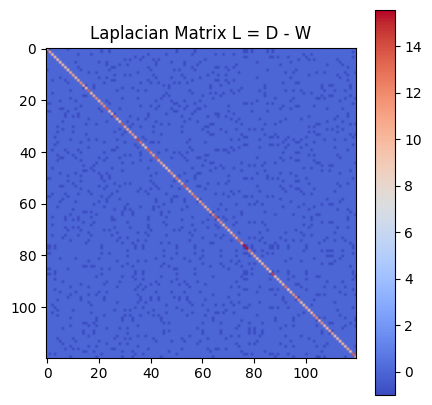

In [ ]:
L = D - W

plt.figure(figsize=(5, 5))
plt.imshow(L, cmap="coolwarm")
plt.title("Laplacian Matrix L = D - W")
plt.colorbar()
plt.show()

### Step 5 - Eigen-decompose L, then Choose k with the Eigengap Heuristic

Handout (page 12): "a larger jump between consecutive small eigenvalues may suggest a natural number of groups."

We plot the smallest eigenvalues and pick k right before the biggest jump.

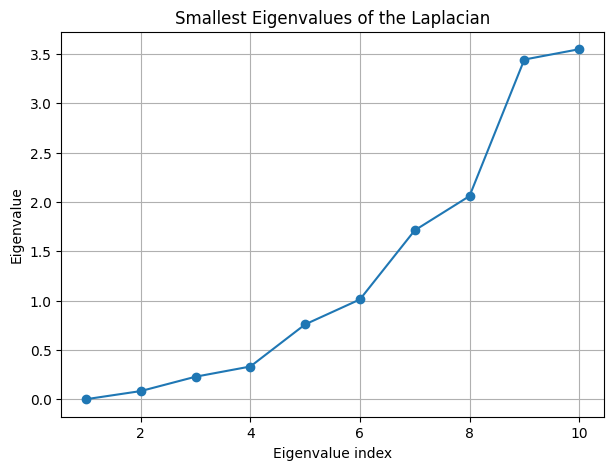

In [ ]:
eigenvalues, eigenvectors = eigh(L)  # ascending order, since L is symmetric

n_show = 10
plt.figure(figsize=(7, 5))
plt.plot(range(1, n_show + 1), eigenvalues[:n_show], marker="o")
plt.title("Smallest Eigenvalues of the Laplacian")
plt.xlabel("Eigenvalue index")
plt.ylabel("Eigenvalue")
plt.grid(True)
plt.show()

In [ ]:
gaps = np.diff(eigenvalues[:n_show])
best_k = int(np.argmax(gaps) + 1)

print("Eigenvalues:", np.round(eigenvalues[:n_show], 4))
print("Eigengaps:  ", np.round(gaps, 4))
print()
print(f"Largest jump occurs after eigenvalue #{best_k} -> suggested number of clusters k = {best_k}")

Eigenvalues: [0.     0.0826 0.2283 0.3317 0.7588 1.0119 1.7124 2.0601 3.4445 3.5492]
Eigengaps:   [0.0826 0.1457 0.1034 0.4271 0.2531 0.7004 0.3477 1.3844 0.1047]

Largest jump occurs after eigenvalue #8 -> suggested number of clusters k = 8


### Step 6 - Take the k Smallest Eigenvectors -> Spectral Embedding U (the "Unfolding")

This step is **unfolding**: points that are hard to separate with a straight line in `(V1, V2)` become easy to separate as coordinates in `U`.

In [ ]:
k = best_k
U = eigenvectors[:, :k]

print("Spectral embedding U shape:", U.shape)

Spectral embedding U shape: (120, 8)


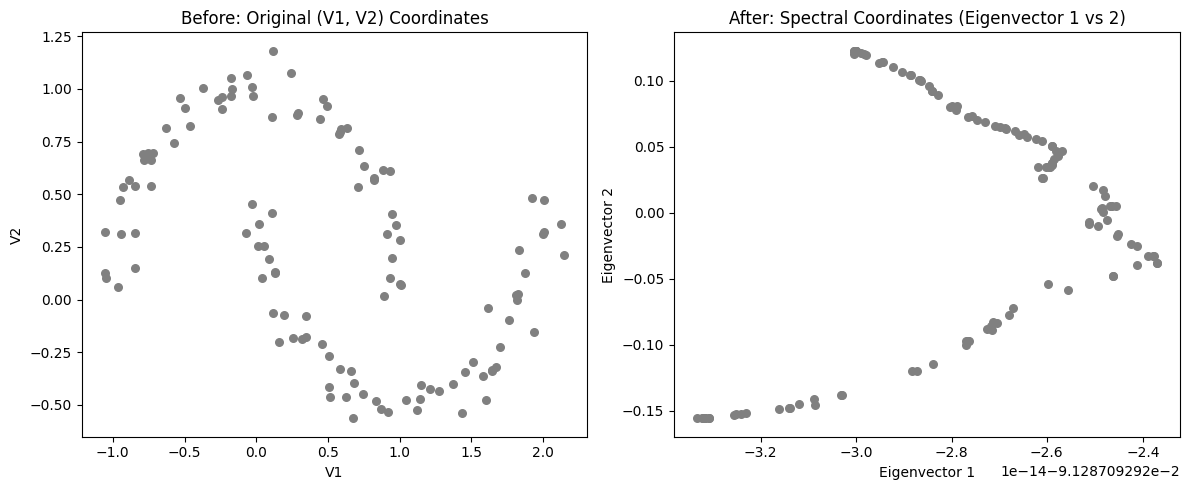

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], color="gray", s=30)
axes[0].set_title("Before: Original (V1, V2) Coordinates")
axes[0].set_xlabel("V1"); axes[0].set_ylabel("V2")

axes[1].scatter(U[:, 0], U[:, 1], color="gray", s=30)
axes[1].set_title("After: Spectral Coordinates (Eigenvector 1 vs 2)")
axes[1].set_xlabel("Eigenvector 1"); axes[1].set_ylabel("Eigenvector 2")

plt.tight_layout()
plt.show()

Notice how the two curved arcs, which overlapped along `V1`/`V2`, become two compact, well-separated blobs in eigenvector space. That is the "unfolding" - k-means is now trivial.

### Step 7 - Run K-Means on the Rows of U

In [ ]:
spectral_kmeans = KMeans(n_clusters=k, n_init=10, random_state=42).fit(U)
spectral_labels = spectral_kmeans.labels_

df["Spectral_Cluster"] = spectral_labels
df.head()

,V1,V2,Spectral_Cluster
0,-0.756377,0.694812,4
1,-0.779523,0.664656,4
2,0.943861,0.198386,2
3,-1.054847,0.127648,4
4,0.242166,1.077621,6


### Final Comparison - Mapping Labels Back onto the Original Data

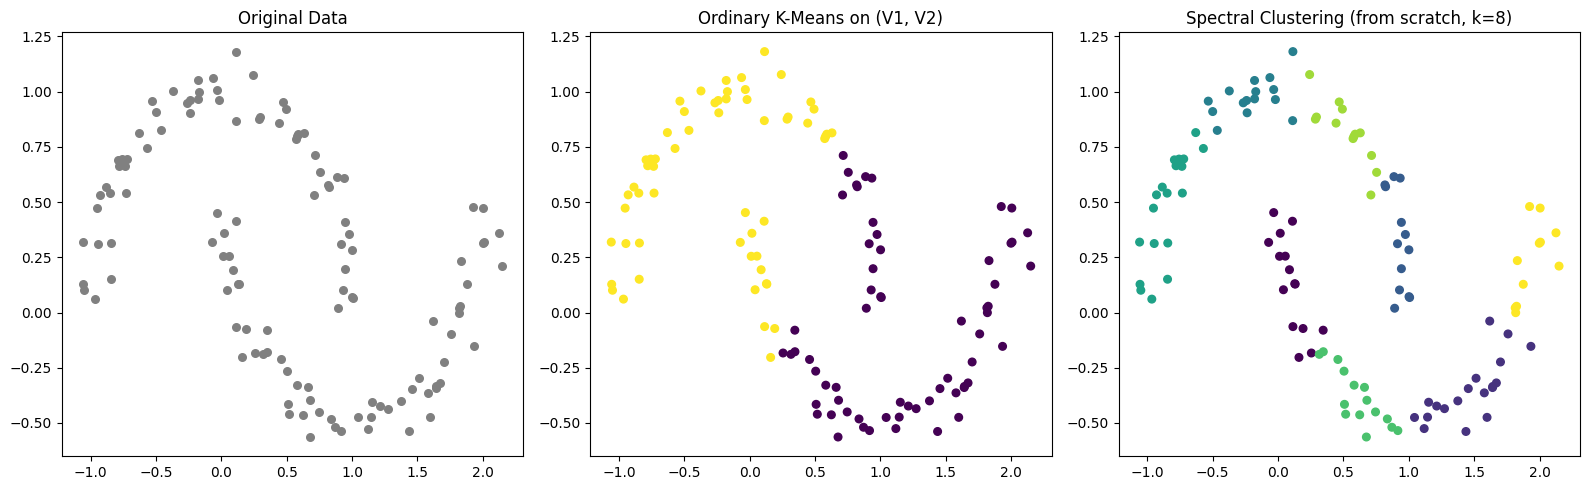

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(df["V1"], df["V2"], color="gray", s=30)
axes[0].set_title("Original Data")

axes[1].scatter(df["V1"], df["V2"], c=kmeans_naive.labels_, cmap="viridis", s=30)
axes[1].set_title("Ordinary K-Means on (V1, V2)")

axes[2].scatter(df["V1"], df["V2"], c=spectral_labels, cmap="viridis", s=30)
axes[2].set_title(f"Spectral Clustering (from scratch, k={k})")

plt.tight_layout()
plt.show()

### Sanity Check - Compare Against Sklearn's `SpectralClustering`

In [ ]:
sklearn_model = SpectralClustering(
    n_clusters=k,
    affinity="nearest_neighbors",
    n_neighbors=k_neighbors,
    assign_labels="kmeans",
    random_state=42,
)
sklearn_labels = sklearn_model.fit_predict(X)

print("ARI, from-scratch vs sklearn SpectralClustering:", round(adjusted_rand_score(spectral_labels, sklearn_labels), 3))
print("ARI, from-scratch vs true moon labels:          ", round(adjusted_rand_score(true_labels, spectral_labels), 3))

ARI, from-scratch vs sklearn SpectralClustering: 0.893
ARI, from-scratch vs true moon labels:           0.247


## Recap - The One-Page Cheat Sheet

| Step | What we did in code |
|---|---|
| 1. Choose k | Read off the eigengap plot |
| 2. Build similarity graph | `NearestNeighbors` k-NN graph, symmetrized |
| 3. Form W | RBF weights restricted to graph edges |
| 4. Form D | Row sums of W on the diagonal |
| 5. Compute L = D - W | Unnormalized graph Laplacian |
| 6. Take k smallest eigenvectors | `scipy.linalg.eigh(L)` -> matrix `U` (the "unfolding") |
| 7. K-means on rows of U | `KMeans(n_clusters=k).fit(U)` -> final labels |

`Original points X -> Graph W -> Laplacian L -> Eigenvectors U -> K-means(U)`